In [2]:
library(igraph) # is written in C and Fortran
library(ggplot2)
library(RColorBrewer)
library(rgl)

# Create Network

In [3]:
# creating a simple empty network by scratch

g <- make_empty_graph()
summary(g)

IGRAPH 379447f D--- 0 0 -- 


In [4]:
# creating a simple directed network with a few edges by scratch
g <- make_graph(edges = c(1,2, 3,4, 5,6), n=8, directed=TRUE)
g # 1 to 2, 3 to 4, 5 to 6, while 7 and 8 are isolated vertices
summary(g)
is_directed(g)

IGRAPH 15dd325 D--- 8 3 -- 
+ edges from 15dd325:
[1] 1->2 3->4 5->6

IGRAPH 15dd325 D--- 8 3 -- 


[1] TRUE

In [5]:
# creating a simple undirected network with a few edges by scratch: way 1
g <- make_graph(edges = c(1,2, 3,4, 5,6), n=8, directed=FALSE)
g # 1--2, 3--4, 5--6 (undirected), while 7 and 8 are isolated vertices
summary(g)
is_directed(g)

IGRAPH a602a10 U--- 8 3 -- 
+ edges from a602a10:
[1] 1--2 3--4 5--6

IGRAPH a602a10 U--- 8 3 -- 


[1] FALSE

NOTE: name the nodes ALWAYS starting from 1 (not 0), ALWAYS use integers !!!


In [6]:
g <- make_graph(~ 1--2, 2--3, 3--4, 4--5, 5--6, 6--1, 4, 5, 6, 7, 8)
summary(g)

IGRAPH 54838aa UN-- 8 6 -- 
+ attr: name (v/c)


In [7]:
# see edge list
get.edgelist(g)

Warning message:
“`get.edgelist()` was deprecated in igraph 2.0.0.
ℹ Please use `as_edgelist()` instead.”


1,2
1,6
2,3
3,4
4,5
5,6


In [8]:
as_edgelist(g) # is a DataFrame

1,2
1,6
2,3
3,4
4,5
5,6


In [9]:
# see adj matrix (igraph default: sparse matrix format)
get.adjacency(g)

Warning message:
“`get.adjacency()` was deprecated in igraph 2.0.0.
ℹ Please use `as_adjacency_matrix()` instead.”


8 x 8 sparse Matrix of class "dgCMatrix"
  1 2 3 4 5 6 7 8
1 . 1 . . . 1 . .
2 1 . 1 . . . . .
3 . 1 . 1 . . . .
4 . . 1 . 1 . . .
5 . . . 1 . 1 . .
6 1 . . . 1 . . .
7 . . . . . . . .
8 . . . . . . . .

In [10]:
# see the combinatorial Laplacian matrix (default: sparse matrix format)
laplacian_matrix(g)

8 x 8 sparse Matrix of class "dgCMatrix"
   1  2  3  4  5  6 7 8
1  2 -1  .  .  . -1 . .
2 -1  2 -1  .  .  . . .
3  . -1  2 -1  .  . . .
4  .  . -1  2 -1  . . .
5  .  .  . -1  2 -1 . .
6 -1  .  .  . -1  2 . .
7  .  .  .  .  .  . 0 .
8  .  .  .  .  .  . . 0

In [11]:
# see the normalized Laplacian (ie, the one describing a RW) (default: sparse matrix format)
laplacian_matrix(g, normalized=TRUE)

Warning message:
“The `normalized` argument of `make_lattice()` provide normalization instead as
of igraph 2.0.3.
ℹ `normalized` is now deprecated, use `normalization` instead.”


8 x 8 sparse Matrix of class "dgCMatrix"
     1    2    3    4    5    6 7 8
1  1.0 -0.5  .    .    .   -0.5 . .
2 -0.5  1.0 -0.5  .    .    .   . .
3  .   -0.5  1.0 -0.5  .    .   . .
4  .    .   -0.5  1.0 -0.5  .   . .
5  .    .    .   -0.5  1.0 -0.5 . .
6 -0.5  .    .    .   -0.5  1.0 . .
7  .    .    .    .    .    .   . .
8  .    .    .    .    .    .   . .

In [12]:
# check if the latest sums to zero along
colSums(laplacian_matrix(g, normalized=TRUE, sparse=F)) # if sparse=T, error

1            2            3            4            5            6 
2.220446e-16 2.220446e-16 2.220446e-16 2.220446e-16 2.220446e-16 2.220446e-16 
           7            8 
0.000000e+00 0.000000e+00

# Nodes

In [13]:
# view and count nodes
V(g)
vcount(g)

+ 8/8 vertices, named, from 54838aa:
[1] 1 2 3 4 5 6 7 8

[1] 8

In [14]:
# node attributes
V(g)$name
V(g)$label
V(g)$label <- letters[1:vcount(g)]
V(g)$label

[1] "1" "2" "3" "4" "5" "6" "7" "8"

NULL

[1] "a" "b" "c" "d" "e" "f" "g" "h"

In [15]:
V(g)$color
V(g)$color <- rainbow(vcount(g))
V(g)$color

NULL

[1] "#FF0000" "#FFBF00" "#80FF00" "#00FF40" "#00FFFF" "#0040FF" "#8000FF"
[8] "#FF00BF"

In [16]:
# add nodes
g <- add_vertices(g, 3)

In [17]:
g

IGRAPH 3ae772c UN-- 11 6 -- 
+ attr: name (v/c), label (v/c), color (v/c)
+ edges from 3ae772c (vertex names):
[1] 1--2 1--6 2--3 3--4 4--5 5--6

In [18]:
# delete a node with invalid ID
g <- delete_vertices(g, 10)
g

IGRAPH ad4c25a UN-- 10 6 -- 
+ attr: name (v/c), label (v/c), color (v/c)
+ edges from ad4c25a (vertex names):
[1] 1--2 1--6 2--3 3--4 4--5 5--6

In [19]:
# delete a node with valid ID
g <- delete_vertices(g, 8)
g

IGRAPH 6af4a32 UN-- 9 6 -- 
+ attr: name (v/c), label (v/c), color (v/c)
+ edges from 6af4a32 (vertex names):
[1] 1--2 1--6 2--3 3--4 4--5 5--6

# Edges

In [20]:
# view and count edges
E(g)
ecount(g)

+ 6/6 edges from 6af4a32 (vertex names):
[1] 1--2 1--6 2--3 3--4 4--5 5--6

[1] 6

In [21]:
# check their list
E(g)

# get their weights
E(g)$weight 

+ 6/6 edges from 6af4a32 (vertex names):
[1] 1--2 1--6 2--3 3--4 4--5 5--6

NULL

In [22]:
# set their weights
E(g)$weight <- rpois(ecount(g),2) + 1 # +1 to avoid zero weights
E(g)$weight

[1] 5 2 4 3 7 2

In [23]:
# add edges
g <- add_edges(g, edges=c(2,7, 3,1))

In [24]:
# delete an edge 
idx <- get.edge.ids(g, c(2,7))
g <- delete_edges(g, idx)
E(g)

Warning message:
“`get.edge.ids()` was deprecated in igraph 2.1.0.
ℹ Please use `get_edge_ids()` instead.”


+ 7/7 edges from afcd8d8 (vertex names):
[1] 1--2 1--6 2--3 3--4 4--5 5--6 1--3

# Create from Data and Plot

In [25]:
set.seed(12345)
my_edges <- data.frame(from=sample(letters, 10), to=sample(letters, 10), weight=runif(10))
my_edges

from,to,weight
<chr>,<chr>,<dbl>
n,h,0.1877124
s,g,0.6818336
p,f,0.3701041
k,a,0.3616256
b,l,0.8687949
w,t,0.9041547
f,z,0.6174246
g,v,0.1340316
j,c,0.7821933


In [26]:
# creating a simple graph from an edges list
g <- graph_from_data_frame(my_edges, directed=TRUE)
summary(g)

IGRAPH ca44200 DNW- 18 10 -- 
+ attr: name (v/c), weight (e/n)


In [27]:
# same, but customizing the ordering of nodes
nodes_ordering <- sort(union(my_edges$from, my_edges$to)) # union gives the same V(g)$name object
nodes_ordering
g <- graph_from_data_frame(my_edges, directed=TRUE, vertices=nodes_ordering)

[1] "a" "b" "c" "f" "g" "h" "i" "j" "k" "l" "n" "p" "q" "s" "t" "v" "w" "z"

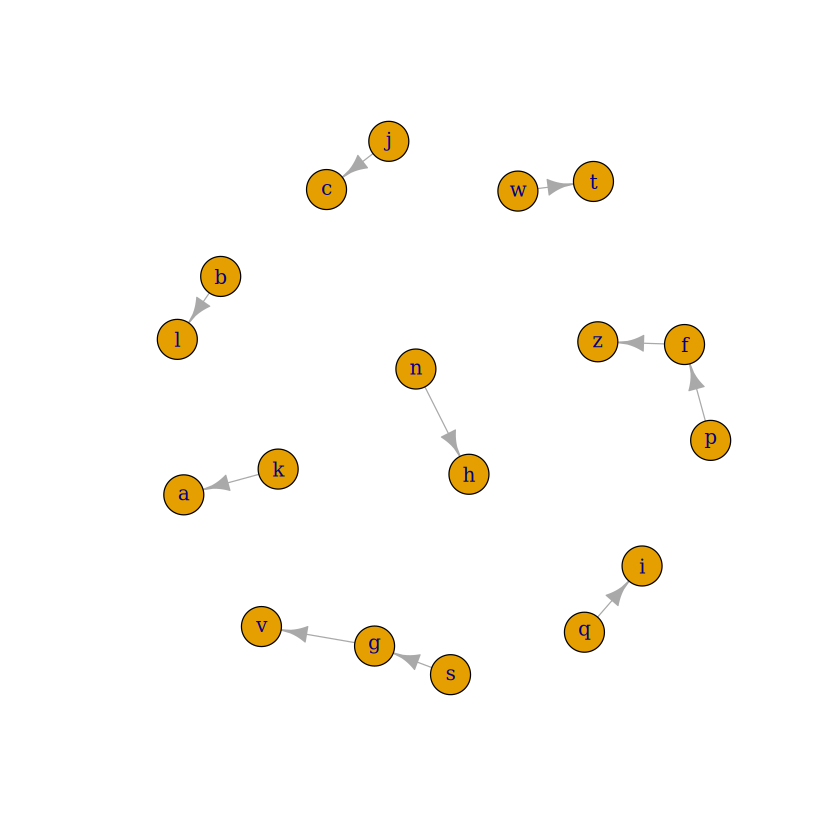

In [28]:
plot(g)

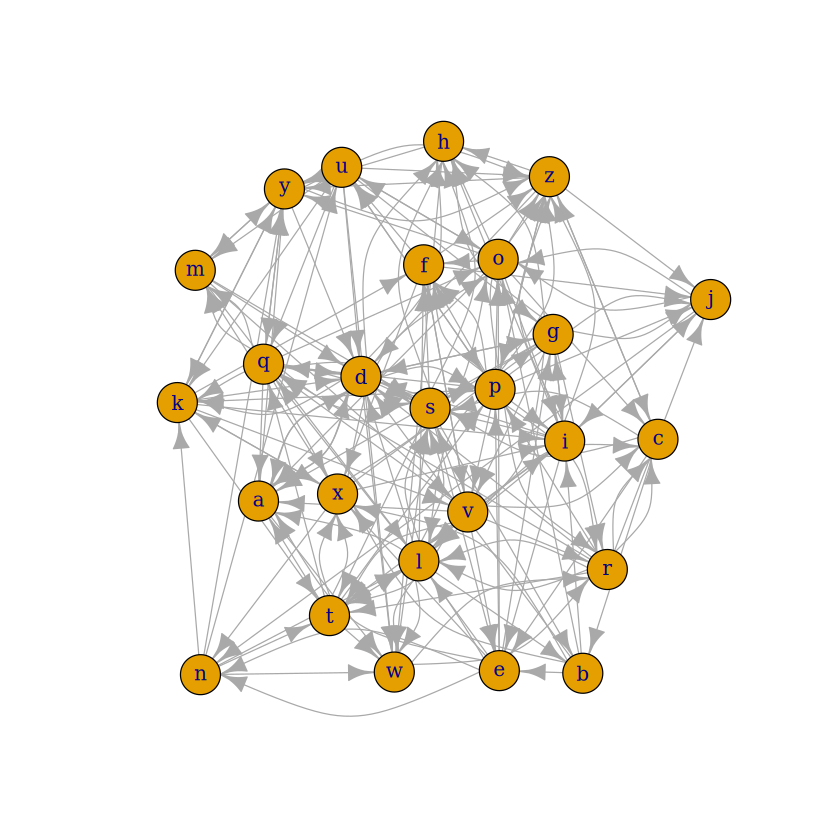

In [29]:
# more complex
n <- 200
my_edges <- data.frame(from=sample(letters, n, replace=TRUE), to=sample(letters, n, replace=TRUE), weight=runif(n))

g <- graph_from_data_frame(my_edges, directed=TRUE)
plot(g)

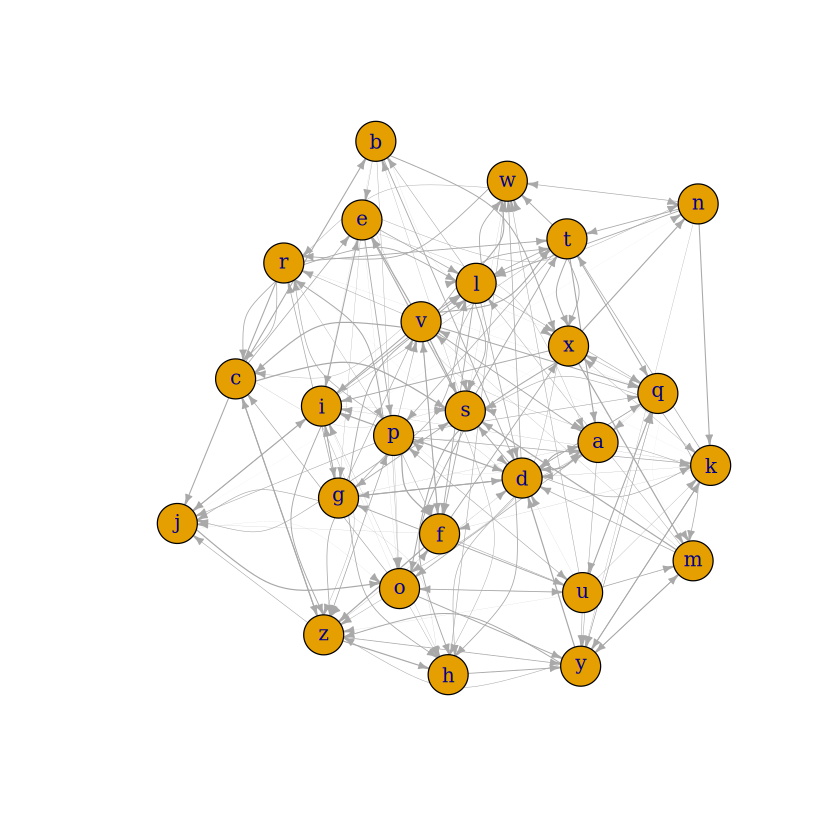

In [30]:
# use also weights and change arrow size
plot(g, edge.width=E(g)$weight, edge.arrow.size=0.4)

## Layout

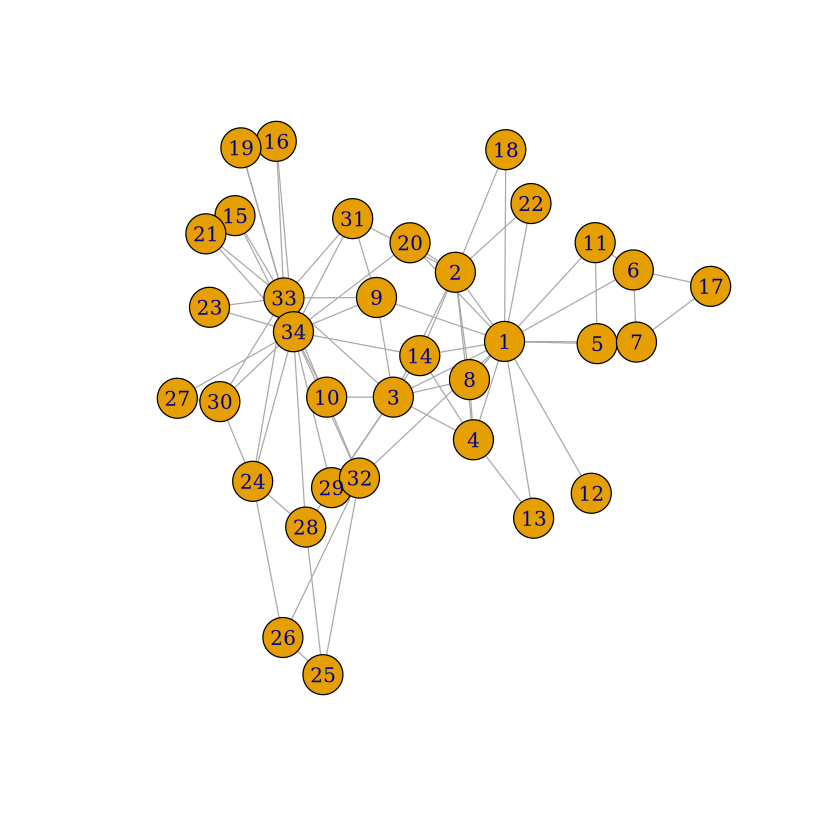

In [31]:
g <- make_graph('Zachary')
plot(g)

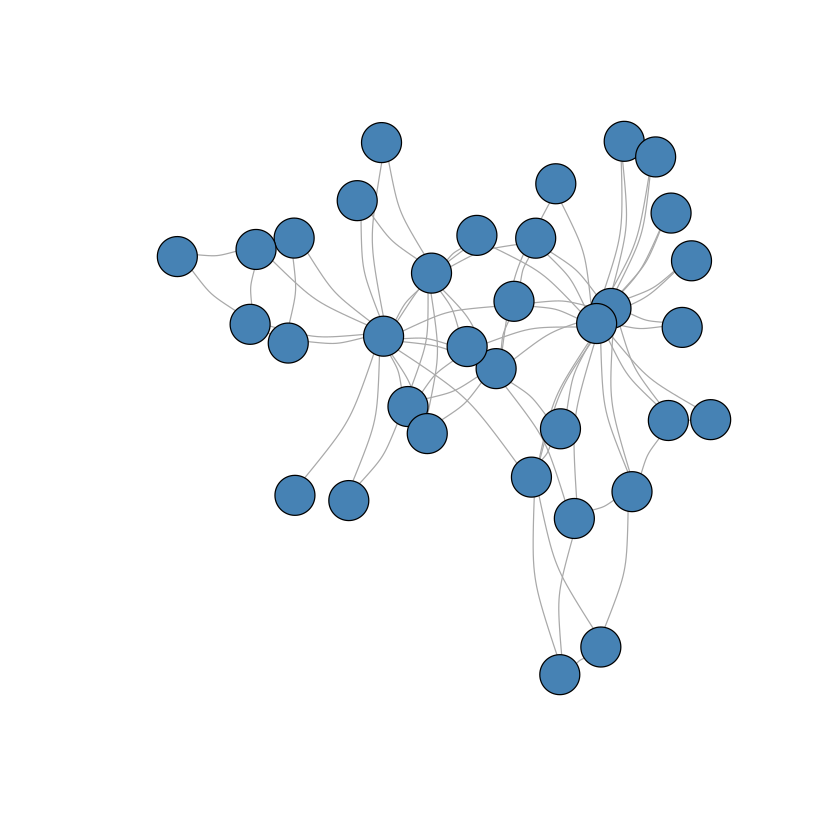

In [32]:
# remove labels and change node colors, curve edges a little
plot(g, vertex.color="steelblue", vertex.label=NA, edge.curved=0.2)

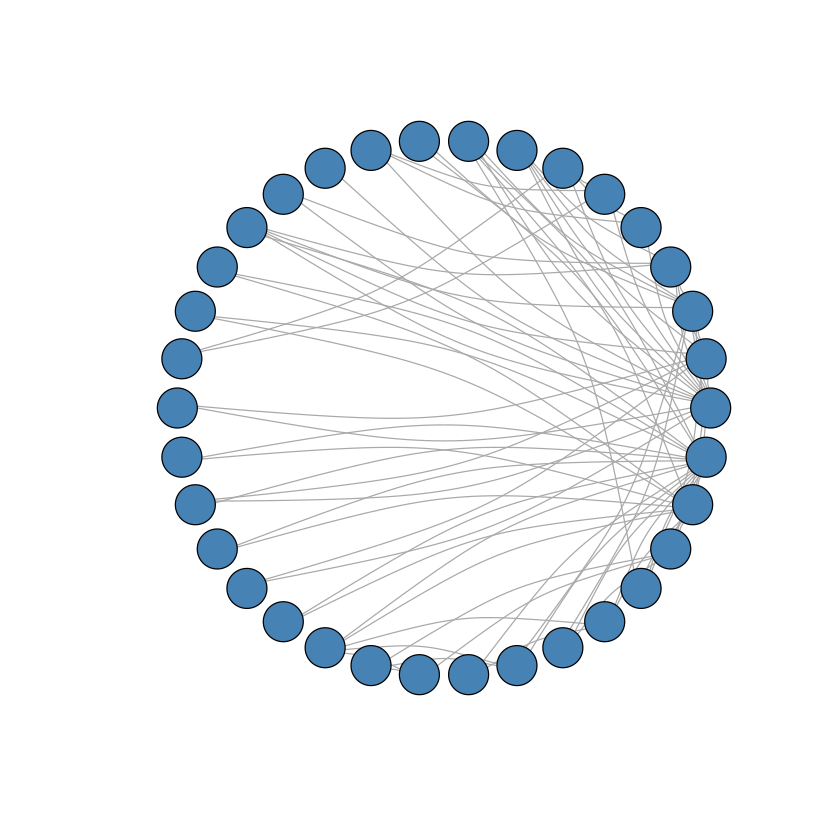

In [33]:
lay <- layout_in_circle(g)
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.curved=0.2)

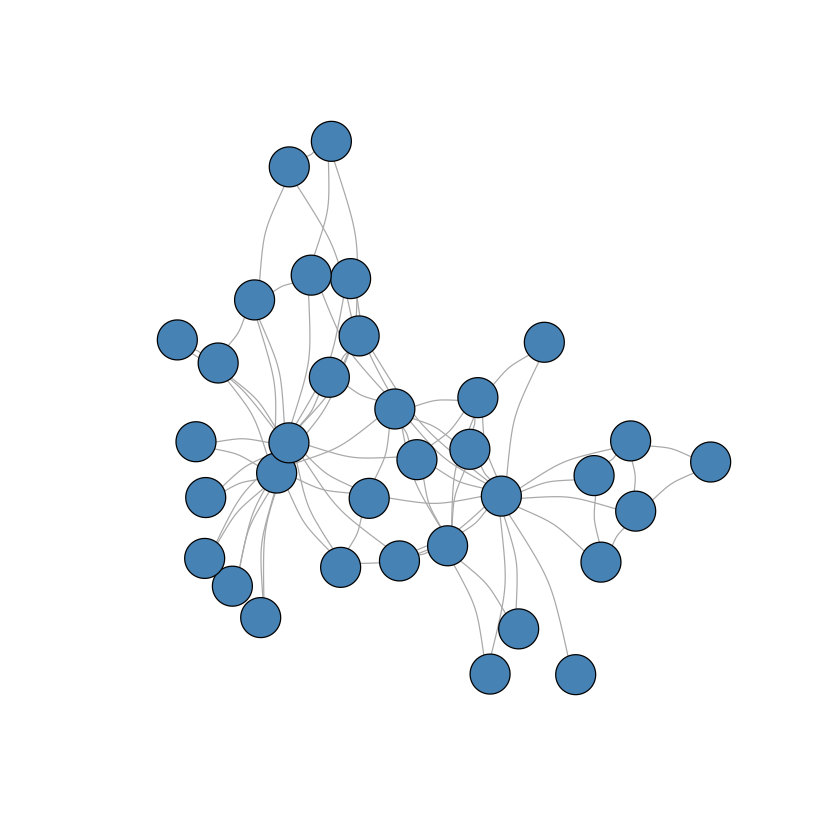

In [34]:
# Fruchterman-Reingold layout => it tries to place the nodes in a nice way (see on internet how - opt problem)
lay <- layout_with_fr(g)
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.curved=0.2)

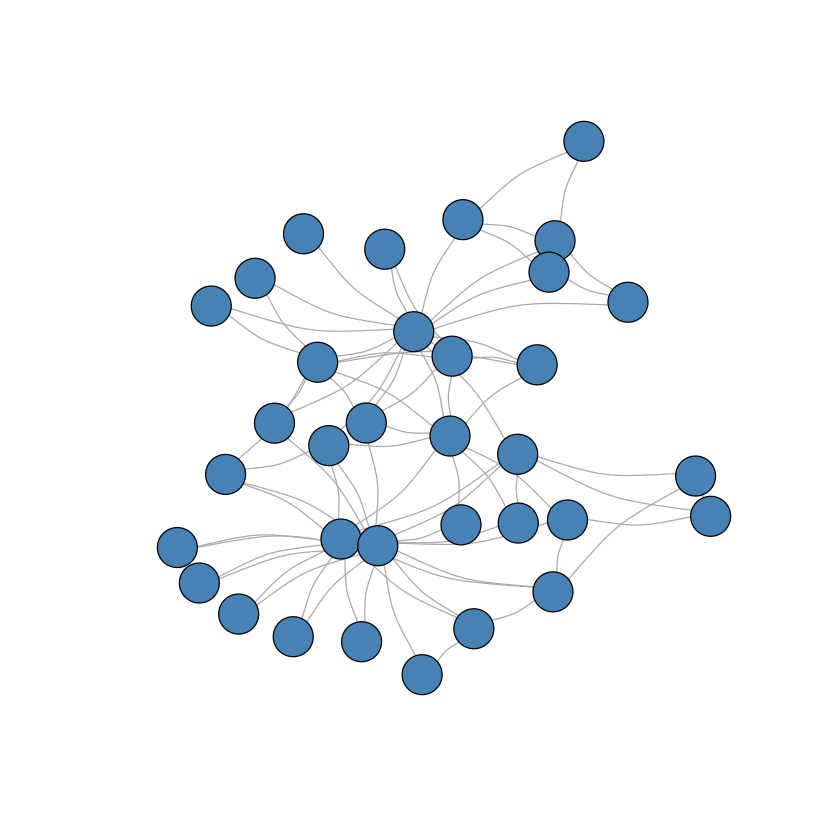

In [35]:
# Kamada-Kawai layout
lay <- layout_with_kk(g)
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.curved=0.2)

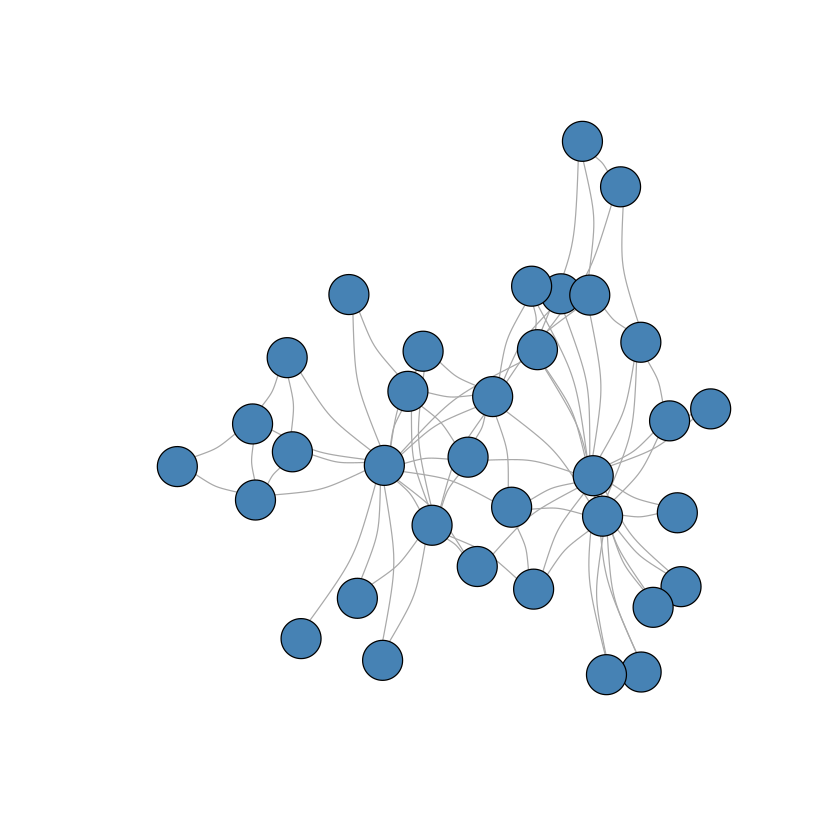

In [36]:
# layout_nicely(g): it is lighter than the previous two (which tends to show the hubs nicely)
lay = layout_nicely(g)
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.curved=0.2)

# Basic Models

Warning message:
“`erdos.renyi.game()` was deprecated in igraph 0.8.0.
ℹ Please use `sample_gnp()` instead.”


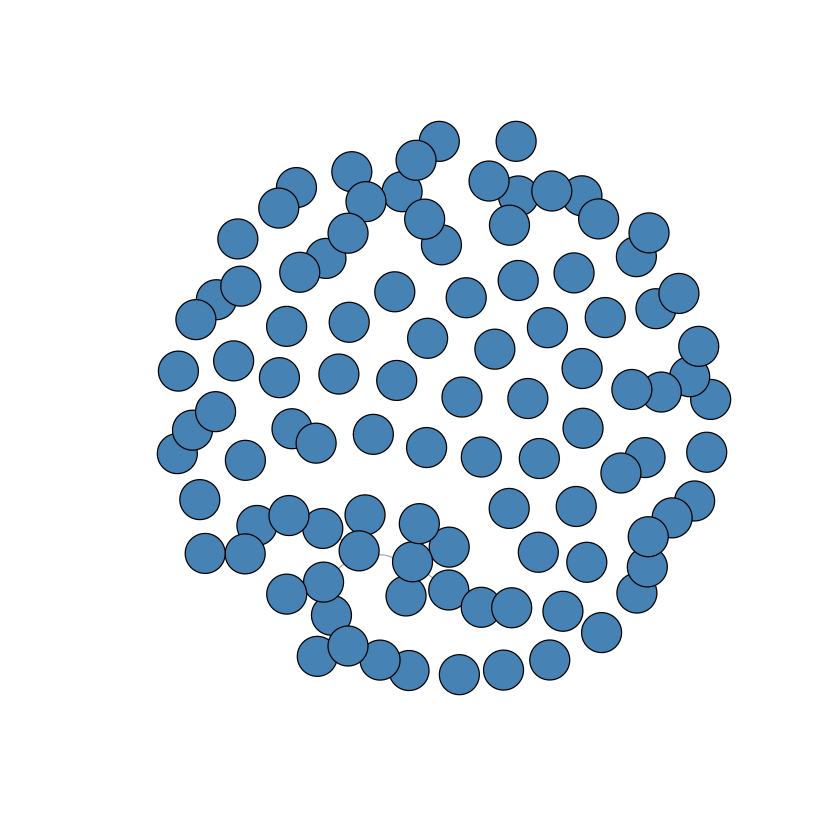

In [37]:
N <- 100

# ERDOS-RENYI
# at the percolation point
g <- erdos.renyi.game(N, p=1/N, directed=F)
lay <- layout_with_fr(g)
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.curved=0.2)

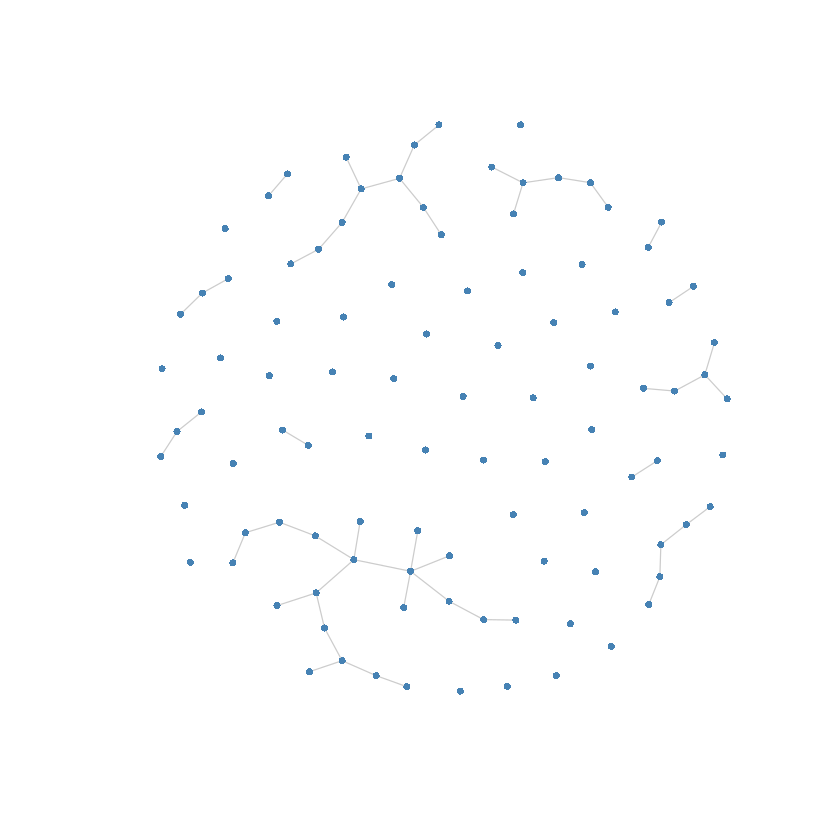

In [38]:
# fix the visualization
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.color="gray80", vertex.size=2.5, vertex.frame.color=NA)

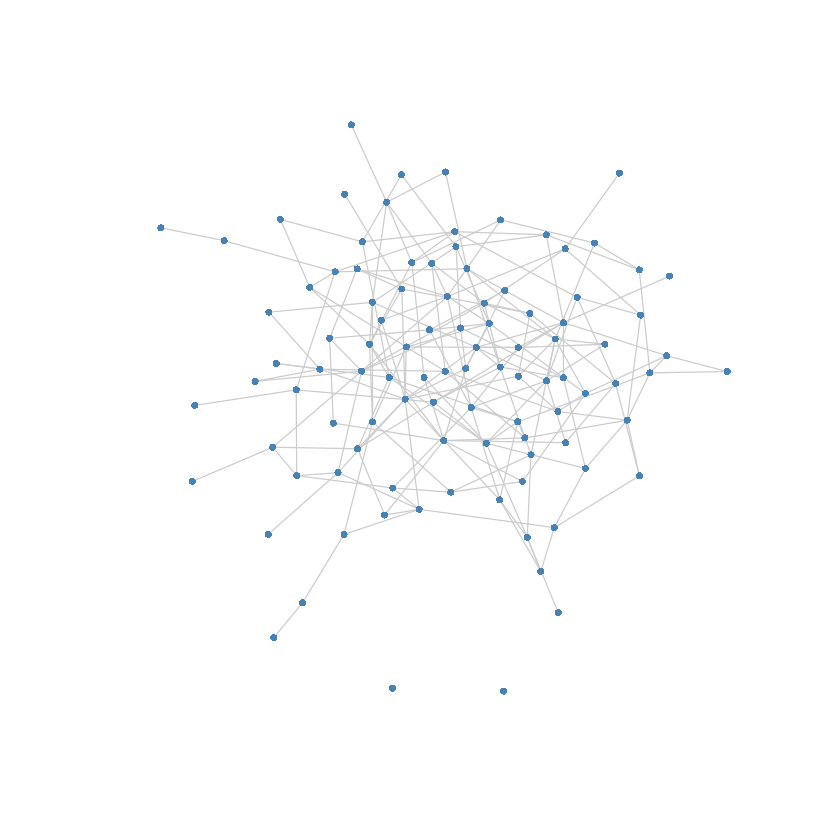

In [39]:
# above the percolation point
g <- erdos.renyi.game(N, p=log(N)/N, directed=F)
lay <- layout_with_fr(g)
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.color="gray80", vertex.size=2.5, vertex.frame.color=NA)

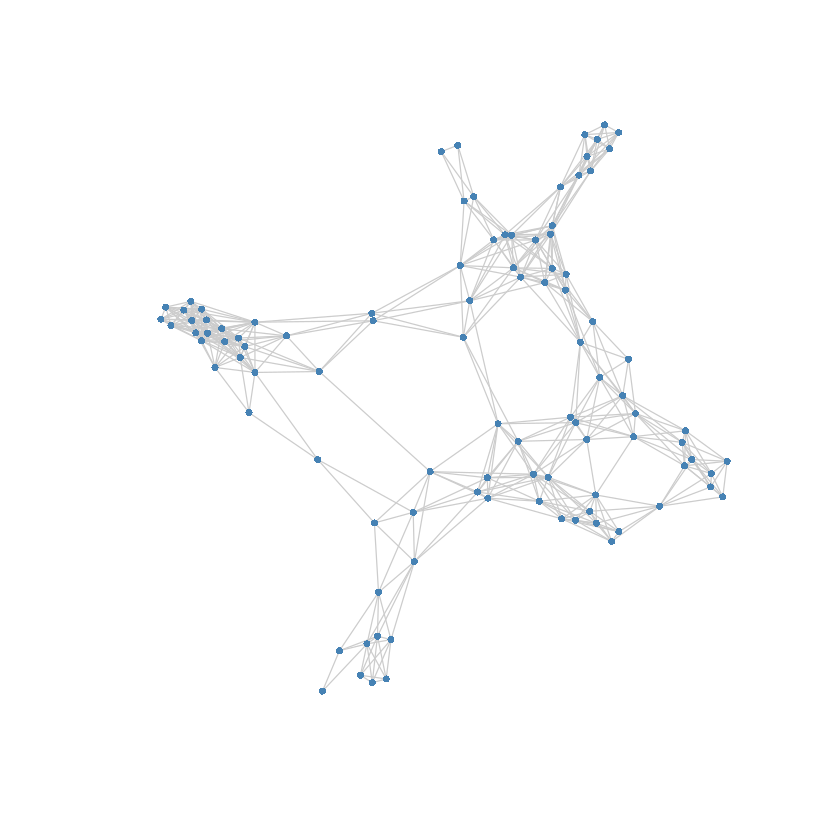

In [40]:
# GEOMETRIC RANDOM GRAPH
g <- sample_grg(N, radius=0.2)
lay <- layout_with_fr(g)
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.color="gray80", vertex.size=2.5, vertex.frame.color=NA)

Warning message:
“`barabasi.game()` was deprecated in igraph 2.0.0.
ℹ Please use `sample_pa()` instead.”


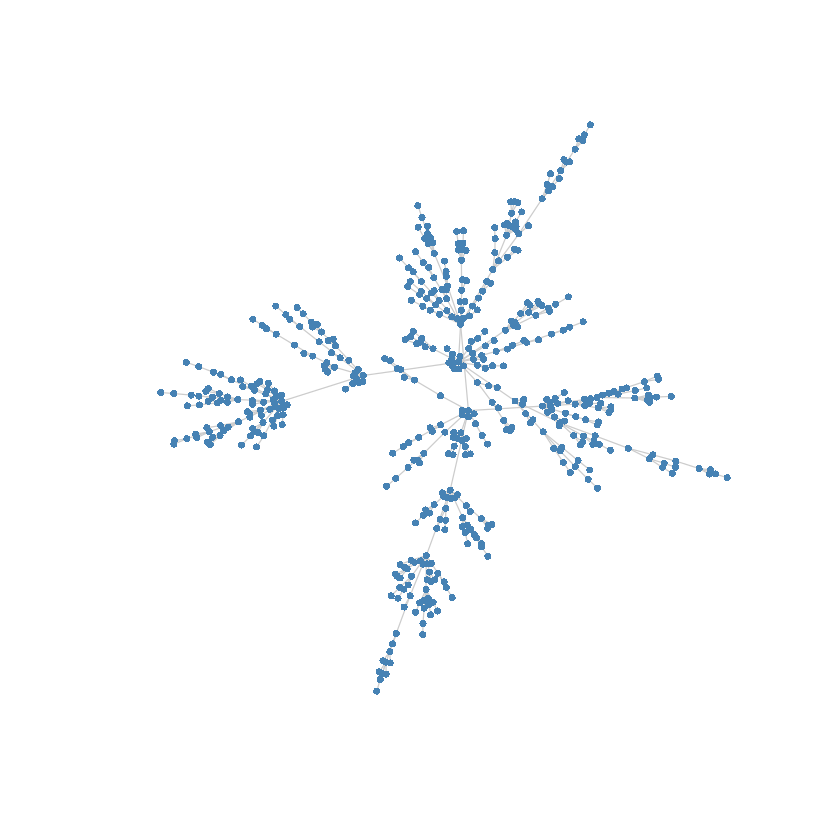

In [41]:
# BARABASI-ALBERT
N <- 500
g <- barabasi.game(N, m=1, directed=FALSE)
lay <- layout_with_fr(g)
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.color="gray80", vertex.size=2.5, vertex.frame.color=NA)

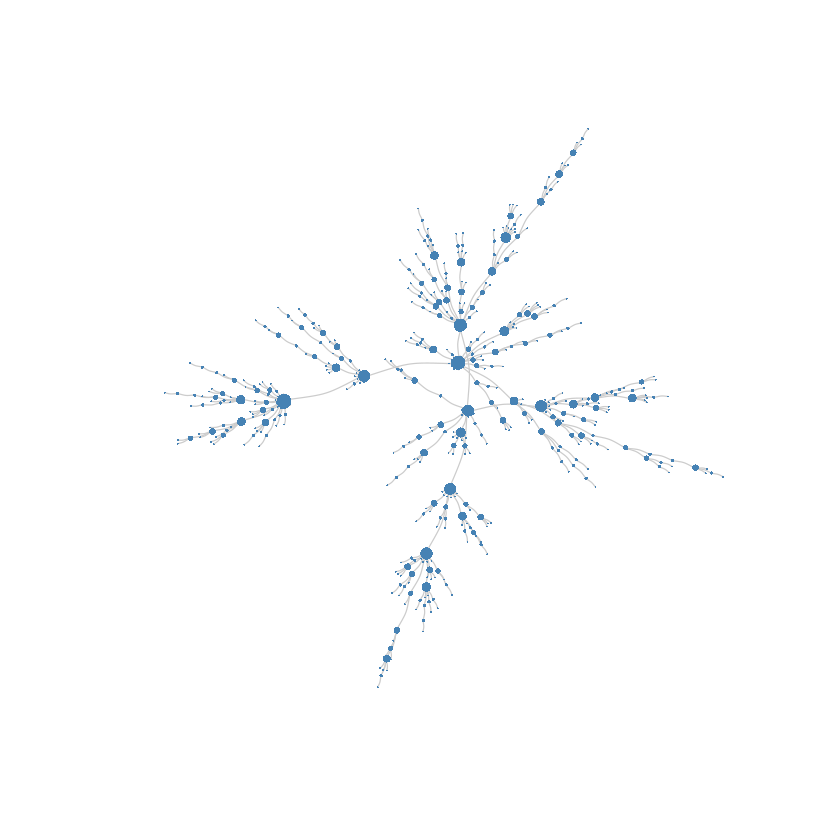

In [42]:
# highlight degree of nodes
plot(g, vertex.color="steelblue", vertex.label=NA, edge.curved=0.2, layout=lay, vertex.size=4*log10(degree(g)), edge.color="gray80", vertex.frame.color=NA)

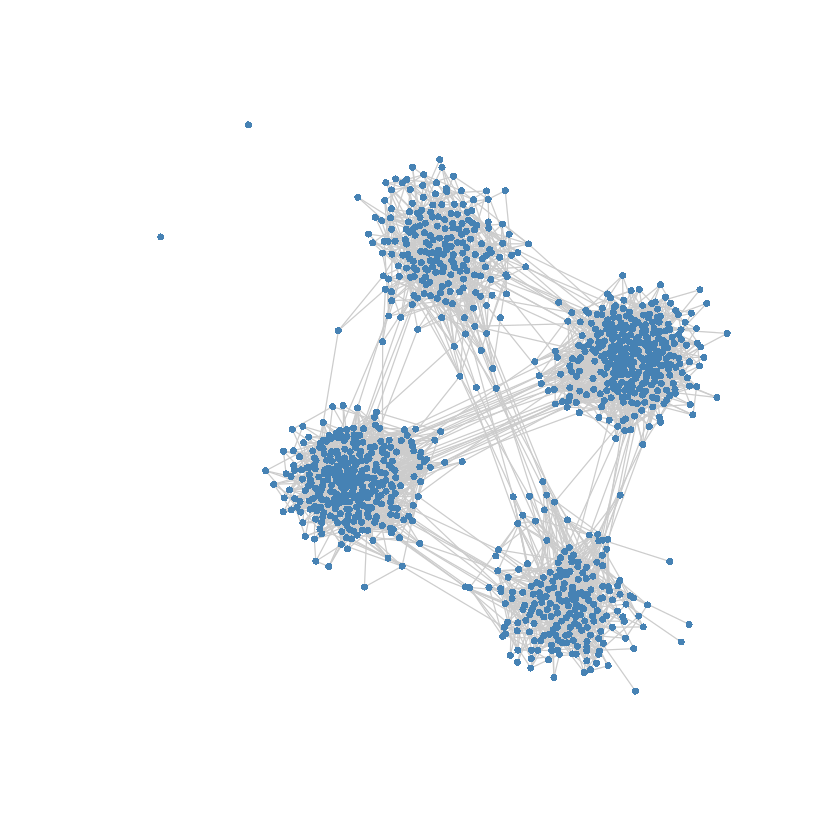

In [43]:
# Sstochastic Block Model with 4 groups
N <- 1000
OM <- matrix(0.0003, ncol=4, nrow=4)
diag(OM) <- 0.03
g <- sample_sbm(N, pref.matrix=OM, block.sizes=c(200, 200, 300, 300))
lay <- layout_with_fr(g)
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.color="gray80", vertex.size=2.5, vertex.frame.color=NA)


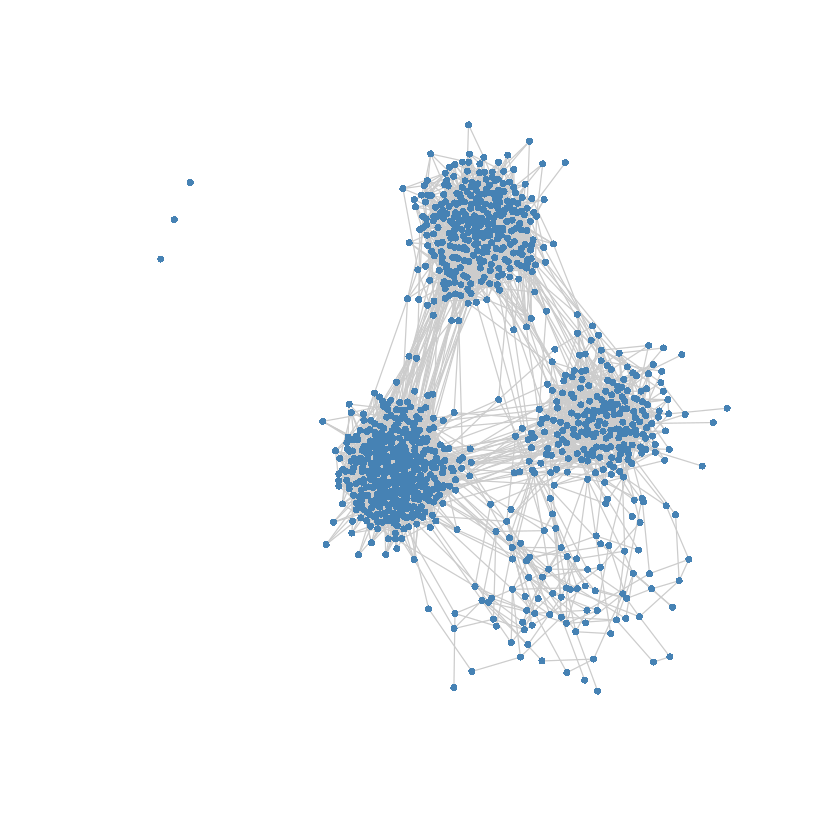

In [44]:
# more complex
OM <- matrix(runif(4*4,0.3/N,0.5/N), ncol=4, nrow=4)
diag(OM) <- runif(4, 3*log(N)/N, 5*log(N)/N)
# symmetrize it
OM <- (OM + t(OM))/2
g <- sample_sbm(N, pref.matrix=OM, block.sizes=c(100, 200, 300, 400))
lay <- layout_with_fr(g)
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.color="gray80", vertex.size=2.5, vertex.frame.color=NA)